Starting Model Consistency Analysis...
Analyzing folder: ../outputs
--------------------------------------------------
-1
1
-1
1
-1
1
-1
1
Qwen_QwQ-32B -> Qwen_QwQ-32B: 0.982 (54/55)

Found 1 model pair combinations
--------------------------------------------------


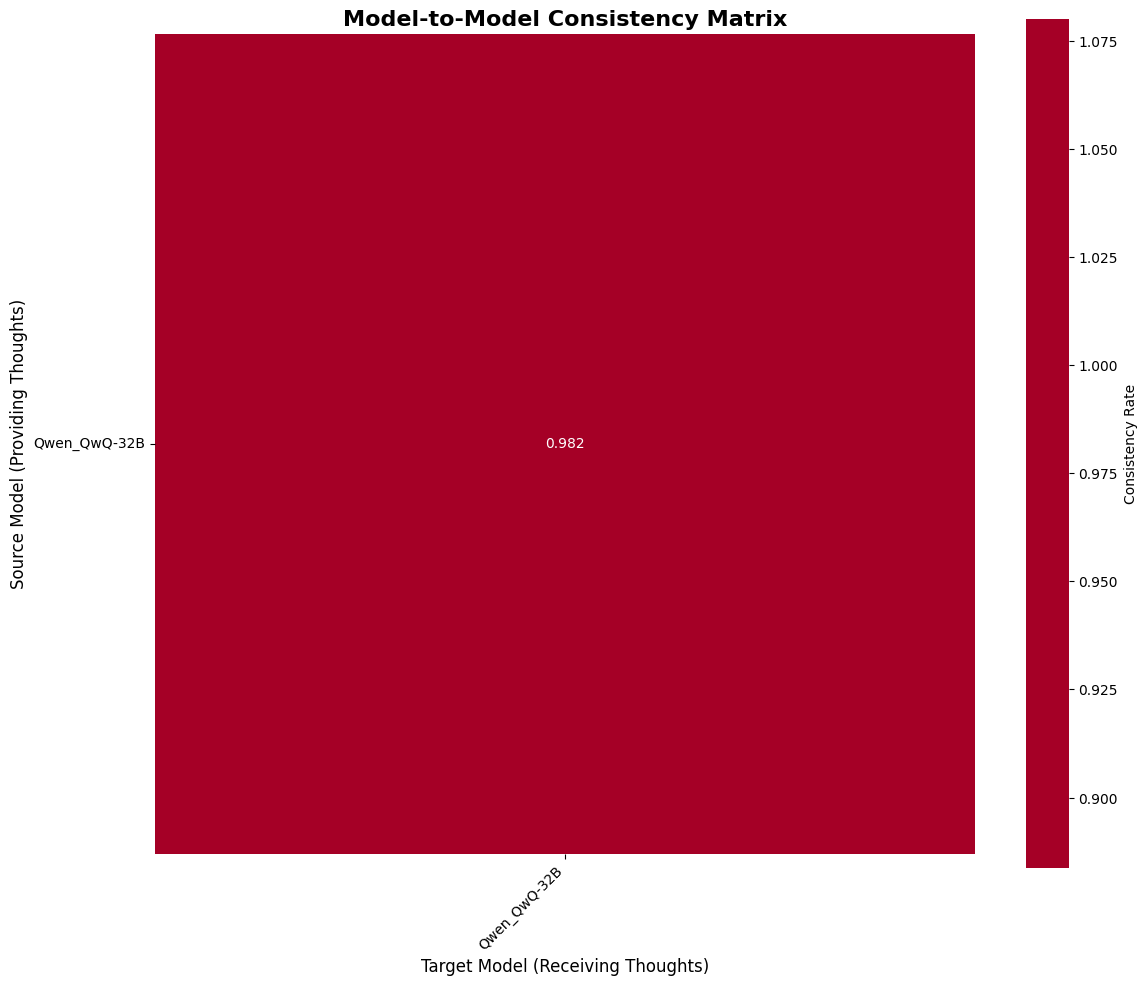

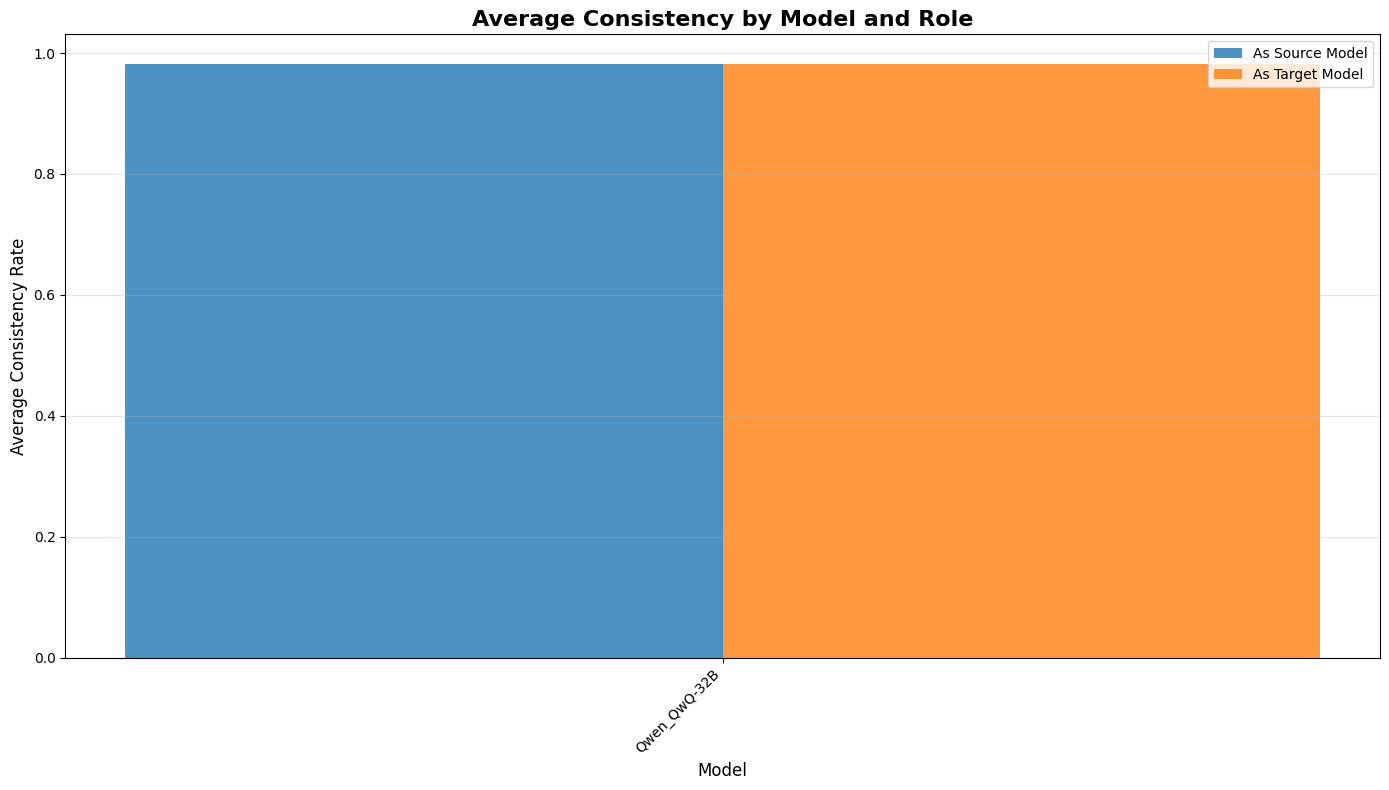


✓ All plots saved to: model_consistency_analysis.pdf

OVERALL CONSISTENCY ANALYSIS SUMMARY
Source-to-Target Statistics:
  Mean Consistency: 0.982
  Median Consistency: 0.982
  Std Dev: 0.000
  Min Consistency: 0.982
  Max Consistency: 0.982

Total Model Pairs Analyzed: 1
Number of Models: 1
Models: Qwen_QwQ-32B


In [1]:
import os
import json
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages

def parse_jsonl_file(filepath):
    """Parse a JSONL file and return list of data points."""
    data_points = []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    data = json.loads(line)
                    data_points.append(data)
                except json.JSONDecodeError as e:
                    print(f"Error parsing line in {filepath}: {e}")
                    continue
    
    return data_points

def check_consistency(data_point):
    """
    Check if two models are consistent on a data point.
    Returns 1 if consistent, 0 if not consistent.
    """
    llm_answer = data_point.get("LLM Answer", "")
    target_answer = data_point.get("Target Answer", "")

    #Pre-check: didn't reach ans:
    patterns = ["not defined", "N/A", "does not match"]

    if any(p in llm_answer for p in patterns) or any(p in target_answer for p in patterns):
        return None
    
    # First check: exact match
    if llm_answer == target_answer:
        return 1
    
    # Second check: both results are "Correct"
    result = data_point.get("Result", "")
    target_result = data_point.get("Target Result", "")
    
    if result == "Correct" and target_result == "Correct":
        return 1
    print(llm_answer)
    print(target_answer)
    print("===============")
    return 0

def extract_model_names(filename):
    """Extract source and target model names from filename."""
    # Pattern: {Model A}_thoughts_to_{Model B}.jsonl
    pattern = r'(.+)_thoughts_to_(.+)_zero_shot_full.jsonl'
    match = re.match(pattern, filename)
    
    if match:
        return match.group(1), match.group(2)
    else:
        return None, None

def calculate_consistency_matrix(folder_path):
    """
    Calculate consistency matrix for all model pairs.
    Returns consistency matrix, model names, and raw data for pairwise analysis.
    """
    consistency_data = {}
    model_names = set()
    data_by_source = {}  # Store raw data points for pairwise analysis
    
    # Process all JSONL files in the folder
    for filename in os.listdir(folder_path):
        if filename.endswith('.jsonl') and '_thoughts_to_' in filename:
            source_model, target_model = extract_model_names(filename)
            
            if source_model and target_model:
                model_names.add(source_model)
                model_names.add(target_model)
                
                filepath = os.path.join(folder_path, filename)
                data_points = parse_jsonl_file(filepath)
                
                if data_points:
                    # Store raw data for pairwise analysis
                    data_by_source[(source_model, target_model)] = data_points
                    
                    # Calculate consistency
                    consistent_count = sum(check_consistency(dp) for dp in data_points
                                          if (val := check_consistency(dp)) is not None)
                    valid_results = [check_consistency(dp) for dp in data_points if check_consistency(dp) is not None]
                    total_count = len(valid_results)
                    consistency_rate = consistent_count / total_count if total_count > 0 else 0
                    
                    consistency_data[(source_model, target_model)] = {
                        'consistency_rate': consistency_rate,
                        'consistent_count': consistent_count,
                        'total_count': total_count
                    }
                    
                    print(f"{source_model} -> {target_model}: {consistency_rate:.3f} ({consistent_count}/{total_count})")
    
    return consistency_data, sorted(list(model_names)), data_by_source

def create_consistency_matrix(consistency_data, model_names):
    """Create a matrix for visualization."""
    n_models = len(model_names)
    matrix = np.zeros((n_models, n_models))
    
    model_to_idx = {model: idx for idx, model in enumerate(model_names)}
    
    for (source, target), data in consistency_data.items():
        if source in model_to_idx and target in model_to_idx:
            i = model_to_idx[source]
            j = model_to_idx[target]
            matrix[i, j] = data['consistency_rate']
    
    return matrix

def calculate_pairwise_target_consistency(consistency_data, model_names, data_by_source):
    """
    Calculate pairwise consistency between target models for each source model.
    This compares how consistently two target models perform on the same data from a source.
    """
    pairwise_consistency = {}
    
    for source_model in model_names:
        # Find all target models for this source
        targets = [target for (src, target) in consistency_data.keys() if src == source_model]
        
        if len(targets) < 2:
            continue
            
        # Compare each pair of target models
        for i in range(len(targets)):
            for j in range(i + 1, len(targets)):
                target_a = targets[i]
                target_b = targets[j]
                
                # Get data for both target models from the same source
                key_a = (source_model, target_a)
                key_b = (source_model, target_b)
                
                if key_a in data_by_source and key_b in data_by_source:
                    data_a = data_by_source[key_a]
                    data_b = data_by_source[key_b]
                    
                    # Compare consistency for each data point
                    consistent_pairs = 0
                    total_pairs = min(len(data_a), len(data_b))
                    
                    for idx in range(total_pairs):
                        consistency_a = check_consistency(data_a[idx])
                        consistency_b = check_consistency(data_b[idx])
                        # dropping pair
                        if consistency_a is None or consistency_b is None:
                            total_pairs = total_pairs - 1
                            continue
                            
                        
                        # Both models are consistent (both get it right or both get it wrong)
                        if consistency_a == consistency_b:
                            consistent_pairs += 1
                    
                    if total_pairs > 0:
                        pairwise_rate = consistent_pairs / total_pairs
                        pairwise_consistency[(source_model, target_a, target_b)] = {
                            'consistency_rate': pairwise_rate,
                            'consistent_pairs': consistent_pairs,
                            'total_pairs': total_pairs
                        }
    
    return pairwise_consistency

def plot_consistency_results(consistency_data, model_names, data_by_source, save_plots=False, save_pdf=True):
    """Create comprehensive visualizations of consistency results."""
    
    # Initialize PDF if saving
    pdf_pages = None
    if save_pdf:
        pdf_pages = PdfPages('model_consistency_analysis.pdf')
    
    # 1. Heatmap of consistency matrix
    plt.figure(figsize=(12, 10))
    consistency_matrix = create_consistency_matrix(consistency_data, model_names)
    
    # Create heatmap
    mask = consistency_matrix == 0  # Mask cells with no data
    sns.heatmap(consistency_matrix, 
                xticklabels=model_names, 
                yticklabels=model_names,
                annot=True, 
                fmt='.3f', 
                cmap='RdYlBu_r',
                center=0.5,
                square=True,
                mask=mask,
                cbar_kws={'label': 'Consistency Rate'})
    
    plt.title('Model-to-Model Consistency Matrix', fontsize=16, fontweight='bold')
    plt.xlabel('Target Model (Receiving Thoughts)', fontsize=12)
    plt.ylabel('Source Model (Providing Thoughts)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    if save_plots:
        plt.savefig('consistency_heatmap.png', dpi=300, bbox_inches='tight')
    if pdf_pages:
        pdf_pages.savefig(plt.gcf(), bbox_inches='tight')
    plt.show()
    
    # 2. Bar plot of average consistency by model
    plt.figure(figsize=(14, 8))
    
    # Calculate average consistency as source and target
    source_avg = defaultdict(list)
    target_avg = defaultdict(list)
    
    for (source, target), data in consistency_data.items():
        source_avg[source].append(data['consistency_rate'])
        target_avg[target].append(data['consistency_rate'])
    
    # Create DataFrame for plotting
    plot_data = []
    for model in model_names:
        if model in source_avg:
            avg_as_source = np.mean(source_avg[model])
            plot_data.append({'Model': model, 'Role': 'As Source', 'Consistency': avg_as_source})
        
        if model in target_avg:
            avg_as_target = np.mean(target_avg[model])
            plot_data.append({'Model': model, 'Role': 'As Target', 'Consistency': avg_as_target})
    
    df = pd.DataFrame(plot_data)
    
    # Create grouped bar plot
    x = np.arange(len(model_names))
    width = 0.35
    
    source_values = [np.mean(source_avg[model]) if model in source_avg else 0 for model in model_names]
    target_values = [np.mean(target_avg[model]) if model in target_avg else 0 for model in model_names]
    
    plt.bar(x - width/2, source_values, width, label='As Source Model', alpha=0.8)
    plt.bar(x + width/2, target_values, width, label='As Target Model', alpha=0.8)
    
    plt.xlabel('Model', fontsize=12)
    plt.ylabel('Average Consistency Rate', fontsize=12)
    plt.title('Average Consistency by Model and Role', fontsize=16, fontweight='bold')
    plt.xticks(x, model_names, rotation=45, ha='right')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    
    if save_plots:
        plt.savefig('consistency_by_model.png', dpi=300, bbox_inches='tight')
    if pdf_pages:
        pdf_pages.savefig(plt.gcf(), bbox_inches='tight')
    plt.show()
    
    # 3. Pairwise Target Model Consistency Analysis
    pairwise_consistency = calculate_pairwise_target_consistency(consistency_data, model_names, data_by_source)
    
    if pairwise_consistency:
        # Create visualization for pairwise target consistency
        fig, axes = plt.subplots(2, 1, figsize=(16, 12))
        
        # 3a. Heatmap of pairwise target consistency
        # Create a matrix for target model pairs
        target_pairs = []
        source_models = []
        pairwise_values = []
        
        for (source, target_a, target_b), data in pairwise_consistency.items():
            pair_name = f"{target_a} vs {target_b}"
            target_pairs.append(pair_name)
            source_models.append(source)
            pairwise_values.append(data['consistency_rate'])
        
        # Create DataFrame for easier plotting
        pairwise_df = pd.DataFrame({
            'Source': source_models,
            'Target_Pair': target_pairs,
            'Consistency': pairwise_values
        })
        
        # Pivot for heatmap
        pivot_df = pairwise_df.pivot(index='Source', columns='Target_Pair', values='Consistency')
        
        sns.heatmap(pivot_df, annot=True, fmt='.3f', cmap='RdYlGn', 
                   ax=axes[0], cbar_kws={'label': 'Pairwise Consistency Rate'})
        axes[0].set_title('Pairwise Target Model Consistency by Source', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Target Model Pairs')
        axes[0].set_ylabel('Source Model')
        
        # 3b. Bar plot of average pairwise consistency
        avg_pairwise = pairwise_df.groupby('Target_Pair')['Consistency'].mean().sort_values(ascending=False)
        
        bars = axes[1].bar(range(len(avg_pairwise)), avg_pairwise.values, alpha=0.7)
        axes[1].set_xlabel('Target Model Pairs', fontsize=12)
        axes[1].set_ylabel('Average Pairwise Consistency', fontsize=12)
        axes[1].set_title('Average Pairwise Consistency Between Target Models', fontsize=14, fontweight='bold')
        axes[1].set_xticks(range(len(avg_pairwise)))
        
        # Improve label formatting to prevent overlap
        labels = []
        for pair in avg_pairwise.index:
            # Split long model names and use abbreviated format
            models = pair.split(' vs ')
            if len(models) == 2:
                # Extract key parts of model names for shorter labels
                model_a = models[0].split('_')[-1] if '_' in models[0] else models[0]
                model_b = models[1].split('_')[-1] if '_' in models[1] else models[1]
                # Further shorten if still too long
                if len(model_a) > 12:
                    model_a = model_a[:12] + '...'
                if len(model_b) > 12:
                    model_b = model_b[:12] + '...'
                labels.append(f"{model_a}\nvs\n{model_b}")
            else:
                labels.append(pair[:20] + '...' if len(pair) > 20 else pair)
        
        axes[1].set_xticklabels(labels, rotation=0, ha='center', fontsize=9)
        axes[1].grid(axis='y', alpha=0.3)
        
        # Adjust spacing between bars if there are many
        if len(avg_pairwise) > 8:
            axes[1].tick_params(axis='x', which='major', labelsize=8)
        
        # Add value labels on bars
        for i, bar in enumerate(bars):
            height = bar.get_height()
            axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                        f'{height:.3f}', ha='center', va='bottom')
        
        plt.tight_layout()
        
        if save_plots:
            plt.savefig('pairwise_target_consistency.png', dpi=300, bbox_inches='tight')
        if pdf_pages:
            pdf_pages.savefig(fig, bbox_inches='tight')
        plt.show()
        
        # 4. Create a detailed summary table plot
        fig, ax = plt.subplots(figsize=(16, 10))
        ax.axis('tight')
        ax.axis('off')
        
        # Create summary table data
        summary_data = []
        
        # Add source-to-target data
        for (source, target), data in consistency_data.items():
            summary_data.append([
                'Source→Target',
                f"{source} → {target}",
                f"{data['consistency_rate']:.3f}",
                f"{data['consistent_count']}/{data['total_count']}",
                ''
            ])
        
        # Add pairwise data
        for (source, target_a, target_b), data in pairwise_consistency.items():
            summary_data.append([
                'Target Pairs',
                f"{source}: {target_a} vs {target_b}",
                f"{data['consistency_rate']:.3f}",
                f"{data['consistent_pairs']}/{data['total_pairs']}",
                'Pairwise'
            ])
        
        # Create table
        table_df = pd.DataFrame(summary_data, 
                               columns=['Analysis Type', 'Comparison', 'Consistency Rate', 
                                       'Count (Consistent/Total)', 'Notes'])
        
        table = ax.table(cellText=table_df.values,
                        colLabels=table_df.columns,
                        cellLoc='center',
                        loc='center',
                        bbox=[0, 0, 1, 1])
        
        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1, 1.5)
        
        # Color code the rows
        for i in range(len(table_df)):
            if table_df.iloc[i]['Analysis Type'] == 'Source→Target':
                for j in range(len(table_df.columns)):
                    table[(i+1, j)].set_facecolor('#E8F4FD')
            else:
                for j in range(len(table_df.columns)):
                    table[(i+1, j)].set_facecolor('#FFF2E8')
        
        # Header styling
        for j in range(len(table_df.columns)):
            table[(0, j)].set_facecolor('#4472C4')
            table[(0, j)].set_text_props(weight='bold', color='white')
        
        plt.title('Detailed Model Consistency Analysis Summary', 
                 fontsize=16, fontweight='bold', pad=20)
        
        if save_plots:
            plt.savefig('consistency_summary_table.png', dpi=300, bbox_inches='tight')
        if pdf_pages:
            pdf_pages.savefig(fig, bbox_inches='tight')
        plt.show()
        
        # Print pairwise consistency summary
        print("\n" + "="*60)
        print("PAIRWISE TARGET MODEL CONSISTENCY")
        print("="*60)
        
        for (source, target_a, target_b), data in pairwise_consistency.items():
            print(f"{source}: {target_a} vs {target_b} = {data['consistency_rate']:.3f} "
                  f"({data['consistent_pairs']}/{data['total_pairs']})")
        
        print(f"\nPairwise Analysis Summary:")
        print(f"  Mean Pairwise Consistency: {np.mean(pairwise_values):.3f}")
        print(f"  Median Pairwise Consistency: {np.median(pairwise_values):.3f}")
        print(f"  Std Dev: {np.std(pairwise_values):.3f}")
    
    # Close PDF if saving
    if pdf_pages:
        pdf_pages.close()
        print(f"\n✓ All plots saved to: model_consistency_analysis.pdf")
    
    # 5. Overall Summary statistics
    print("\n" + "="*60)
    print("OVERALL CONSISTENCY ANALYSIS SUMMARY")
    print("="*60)
    
    all_consistency_rates = [data['consistency_rate'] for data in consistency_data.values()]
    print(f"Source-to-Target Statistics:")
    print(f"  Mean Consistency: {np.mean(all_consistency_rates):.3f}")
    print(f"  Median Consistency: {np.median(all_consistency_rates):.3f}")
    print(f"  Std Dev: {np.std(all_consistency_rates):.3f}")
    print(f"  Min Consistency: {np.min(all_consistency_rates):.3f}")
    print(f"  Max Consistency: {np.max(all_consistency_rates):.3f}")
    
    print(f"\nTotal Model Pairs Analyzed: {len(consistency_data)}")
    print(f"Number of Models: {len(model_names)}")
    print(f"Models: {', '.join(model_names)}")
    
    return consistency_matrix, df, pairwise_consistency

# Main execution
def main(folder_path):
    """Main function to run the consistency analysis."""
    
    print("Starting Model Consistency Analysis...")
    print(f"Analyzing folder: {folder_path}")
    print("-" * 50)
    
    # Calculate consistency data
    consistency_data, model_names, data_by_source = calculate_consistency_matrix(folder_path)
    
    if not consistency_data:
        print("No valid JSONL files found with the expected naming pattern.")
        print("Expected pattern: {Model A}_thoughts_to_{Model B}.jsonl")
        return
    
    print(f"\nFound {len(consistency_data)} model pair combinations")
    print("-" * 50)
    
    # Create visualizations
    consistency_matrix, summary_df, pairwise_data = plot_consistency_results(
        consistency_data, model_names, data_by_source, save_plots=True, save_pdf=True)
    
    return consistency_data, consistency_matrix, model_names, pairwise_data

# Example usage:
if __name__ == "__main__":
    # Replace with your folder path
    folder_path = "../outputs"  # Update this path
    
    # Run the analysis
    results = main(folder_path)
    if results:
        consistency_data, matrix, models, pairwise_data = results